In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("./us_black_congress.csv")

In [15]:
df["South"] = False

In [16]:
south = ['AL', 'AR', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV']

df["South"] = df["State or Territory"].isin(south)


In [17]:
df["Session No"] = (
    df["Congress"].str.extract(r"(\d+)").astype(int)
)

df = df.sort_values(by="Session No")

In [18]:
df_summary = df.groupby(["Session No", "South"]).agg(
    no=("Name", "count")
)

In [19]:
all_congress = list(range(41, 120))
all_south = [False, True]

full_index = pd.MultiIndex.from_product(
    [all_congress, all_south], names=["Congress", "South"]
)

In [20]:
df_summary = df_summary.reindex(full_index, fill_value=0).reset_index()

In [21]:
south_reps = df_summary[df_summary["South"]==True]
non_south_reps = df_summary[df_summary["South"]==False]

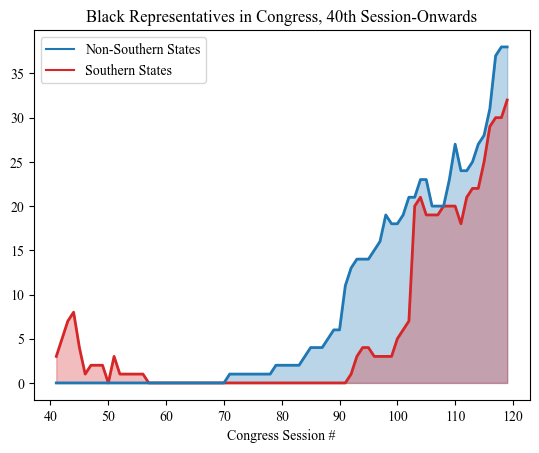

In [29]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(south_reps["Congress"], south_reps["no"], color='tab:red', linestyle='-', marker='', linewidth=2)
plt.plot(non_south_reps["Congress"], non_south_reps["no"], color='tab:blue', linestyle='-', marker='', linewidth=2)
plt.fill_between(non_south_reps["Congress"], non_south_reps["no"], color="tab:blue", alpha=0.3)
plt.fill_between(south_reps["Congress"], south_reps["no"], color="tab:red", alpha=0.3)
plt.title("Black Representatives in Congress, 40th Session-Onwards")
plt.xlabel("Congress Session #")
plt.plot([], [], color='tab:blue',label="Non-Southern States")
plt.plot([], [], color='tab:red', label="Southern States")
plt.legend()